In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("data.csv")

# Display first 5 rows
print(df.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

In [3]:
# Basic Info
# Check dataset structure
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
# Clean Column Names
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [5]:
# Check missing values
print(df.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [6]:
# Create new useful features

# Total approved units
df['Total Approved'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

# Total enrolled units
df['Total Enrolled'] = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']

# Performance ratio
df['Performance'] = df['Total Approved'] / df['Total Enrolled']

# Show updated data
print(df.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                           122.0     

In [7]:
#Basic Analysis
print("Average Age:", df['Age at enrollment'].mean())
print("Max Age:", df['Age at enrollment'].max())
print("Min Age:", df['Age at enrollment'].min())

print("Average Admission Grade:", df['Admission grade'].mean())

Average Age: 23.265144665461122
Max Age: 70
Min Age: 17
Average Admission Grade: 126.97811934900544


In [8]:
#Target Analysis
# Count of each category
print(df['Target'].value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


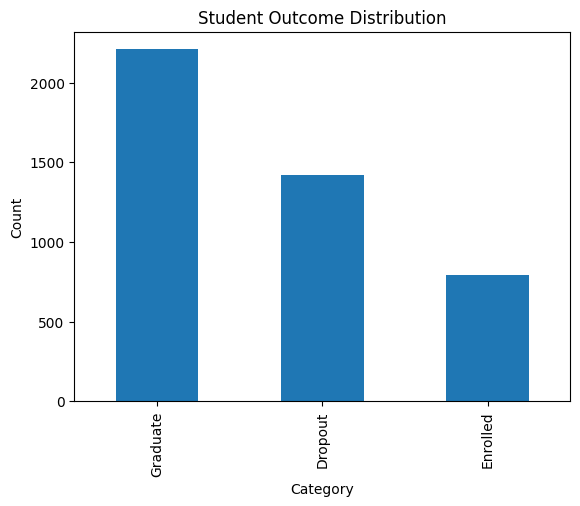

In [9]:
# Bar Graph
plt.figure()
df['Target'].value_counts().plot(kind='bar')
plt.title("Student Outcome Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

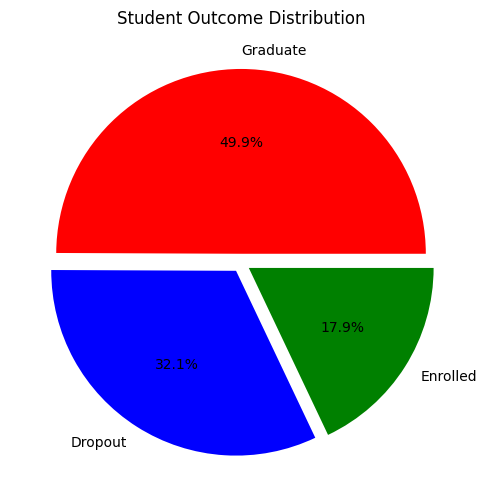

In [10]:
#Pie Chart
# Pie chart of student outcomes
counts = df['Target'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['red','blue','green'], explode=(0.05,0.05,0.05))
plt.title("Student Outcome Distribution")
plt.show()

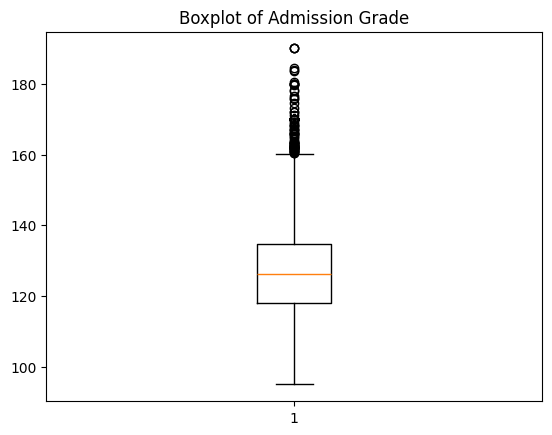

In [11]:
# Boxplot for Admission Grade
plt.figure()
plt.boxplot(df['Admission grade'])
plt.title("Boxplot of Admission Grade")
plt.show()

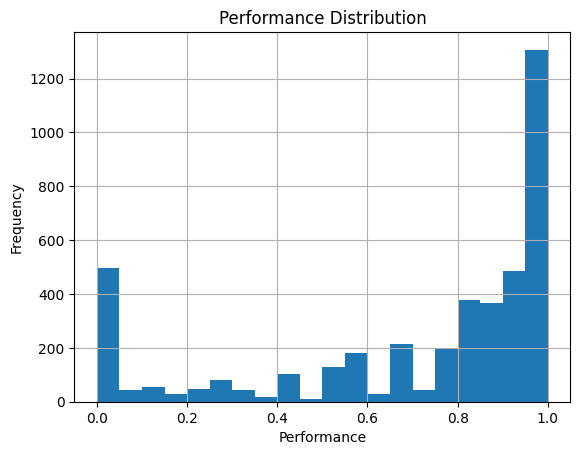

In [12]:
# Performance Distribution 
plt.figure()
df['Performance'].hist(bins=20)
plt.title("Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Frequency")
plt.show()


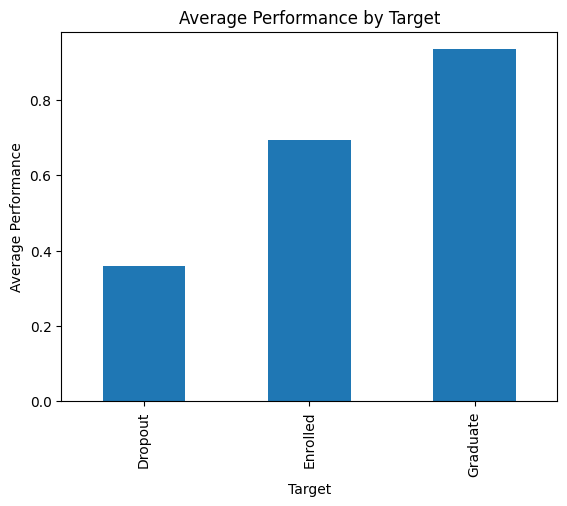

In [13]:
# Target vs Performance 
plt.figure()
df.groupby('Target')['Performance'].mean().plot(kind='bar')
plt.title("Average Performance by Target")
plt.xlabel("Target")
plt.ylabel("Average Performance")
plt.show()


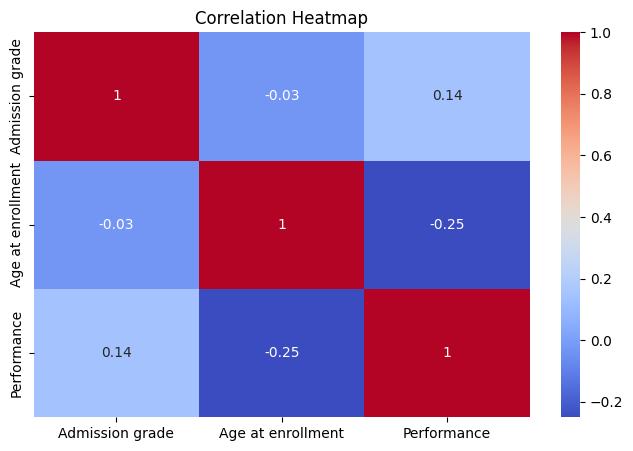

In [14]:
# Heatmap
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df[['Admission grade','Age at enrollment','Performance']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

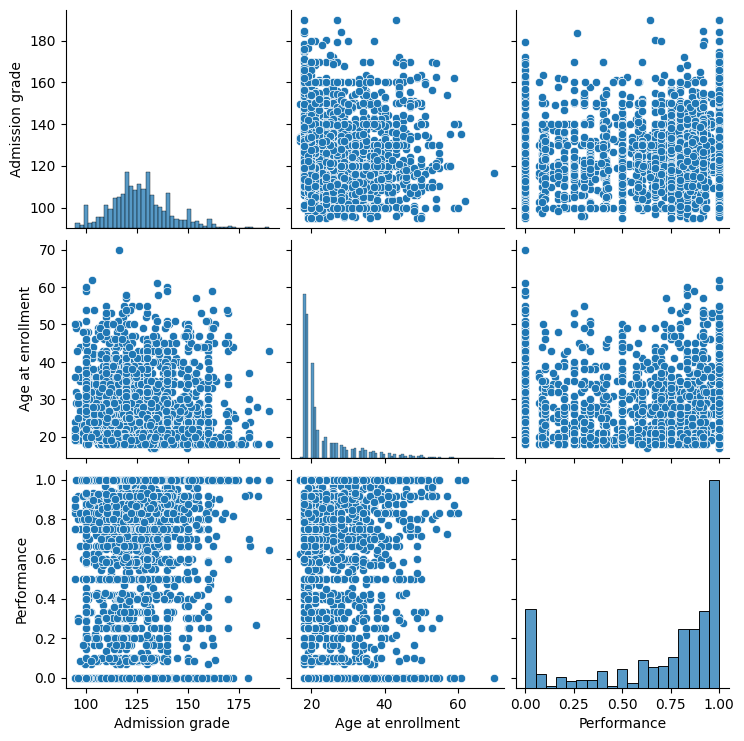

In [15]:
# Pairplot - Shows relationships between variables
sns.pairplot(df[['Admission grade','Age at enrollment','Performance']])
plt.show()

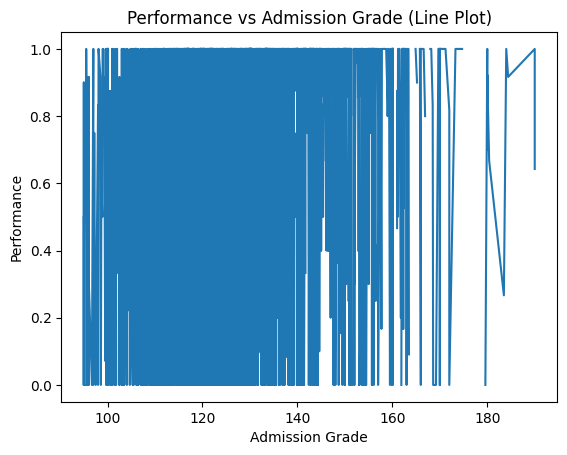

In [16]:
#Line graph 
# Sort values for better visualization
df_sorted = df.sort_values(by='Admission grade')

plt.figure()
plt.plot(df_sorted['Admission grade'], df_sorted['Performance'])
plt.title("Performance vs Admission Grade (Line Plot)")
plt.xlabel("Admission Grade")
plt.ylabel("Performance")
plt.show()

In [37]:
df = pd.read_csv("data.csv")

In [38]:
# Replace infinite values with NaN
import numpy as np

# Replace inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [39]:
# Remove spaces
df['Target'] = df['Target'].astype(str).str.strip()
print(df['Target'].unique())

['Dropout' 'Graduate' 'Enrolled']


In [40]:
print(df.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [41]:
# Ml Model
# Convert Target to numeric
df['Target'] = df['Target'].map({
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
})

In [42]:
print(df['Target'].isnull().sum())

0


In [44]:
# Create new useful features

# Total approved units
df['Total Approved'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

# Total enrolled units
df['Total Enrolled'] = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']

# Performance ratio (approved / enrolled)
df['Performance'] = df['Total Approved'] / df['Total Enrolled']

# Display updated dataset
print(df.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

In [45]:
# Replace infinite values (caused by division)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Final check
print(df.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [46]:

# Correlation between features
print(df[['Admission grade', 'Performance']].corr())

                 Admission grade  Performance
Admission grade         1.000000     0.137954
Performance             0.137954     1.000000


In [47]:
#Define Feature and Target
# Features (input variables)
X = df[['Admission grade', 'Age at enrollment', 'Performance']]

# Target (output variable)
y = df['Target']

In [48]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [49]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Create and train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [50]:
# Predict using test data
y_pred = model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score

# Check accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7288135593220338


In [52]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Train decision tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6508474576271186


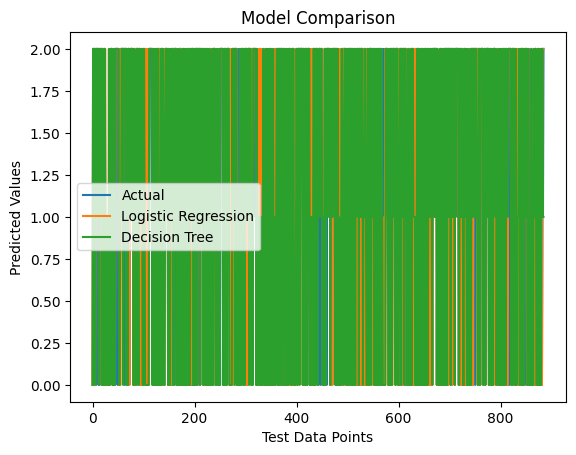

In [53]:
# Model Comparison Graph
# Compare models visually
plt.figure()

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Logistic Regression')
plt.plot(y_pred_dt, label='Decision Tree')

plt.title("Model Comparison")
plt.xlabel("Test Data Points")
plt.ylabel("Predicted Values")

plt.legend()
plt.show()